# Loss Comparison

In this notebook, we compare multiple loss functions for **jaguar re-identification**. In the [Baseline Notebook](jaguar-reidentification-megadescriptor-arcfaceloss.ipynb), **ArcFaceLoss** was used as the baseline. We keep the same training pipeline as in previous experiments. Based on earlier results, we use **DINOv3** as the backbone (see [Backbone Notebook](02_backbone.ipynb)) and apply **blurred backgrounds** (see [Background Interventions Notebook](01_background_interventions.ipynb)), as both improved performance.

The dataset embeddings are generated once. For each loss function, we train an **embedding projection model** and compare the resulting **identity-balanced mAP** on the validation set. The overall training configuration remains largely consistent with the setup used in the [Baseline Notebook](jaguar-reidentification-megadescriptor-arcfaceloss.ipynb). Hyperparameters for each loss are selected to ensure stable training behavior.

The following loss functions are evaluated:

1. **ArcFace Loss**
2. **CosFace Loss**
3. **SphereFace Loss**
4. **Proxy Anchor Loss**
5. **Sub-Center ArcFace Loss**
6. **Center Loss**
7. **Batch-Hard Triplet Loss**


## 1. Setup and Configuration

In [ ]:
EXPERIMENT_NAME = "03_loss_comparison"
RANDOM_SEED = 12 # 42, 66, 102, 305, 12

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    ArcFaceLoss,
    BatchHardTripletLoss,
    CenterLoss,
    CosFaceLoss,
    ProxyAnchorLoss,
    SphereFaceLoss,
    SubCenterArcFaceLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [ ]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    
    # CosFace
    "cosface_margin": 0.35,
    "cosface_scale": 30.0,
    
    # SphereFace
    "sphereface_margin": 4,
    "sphereface_scale": 64.0,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    
    # SubCenterArcFace
    "subcenter_arcface_margin": 0.5,
    "subcenter_arcface_scale": 64.0,
    "subcenter_arcface_num_subcenters": 3,
    
    # BatchHardTriplet
    "batch_hard_triplet_margin": 0.3,
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Scheduler
    "scheduler_factor": 0.5,
    "scheduler_patience": 5,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  arcface_margin: 0.5
  arcface_scale: 64.0
  cosface_margin: 0.35
  cosface_scale: 30.0
  sphereface_margin: 4
  sphereface_scale: 64.0
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  subcenter_arcface_margin: 0.5
  subcenter_arcface_scale: 64.0
  subcenter_arcface_num_subcenters: 3
  batch_hard_triplet_margin: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 12


In [ ]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Create stratified train/validation split to ensure all identities appear in train and validation set.

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


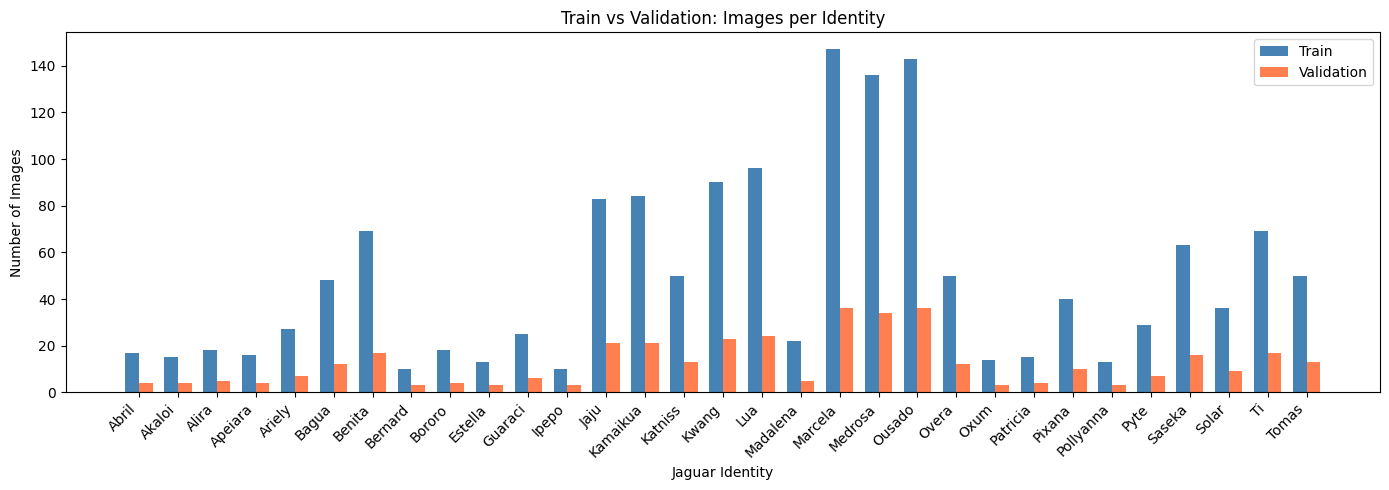


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [ ]:
# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [ ]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda


In [ ]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [ ]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [ ]:
image_dataset = BlurImageDataset(
    image_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [ ]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=filenames,
    device=device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


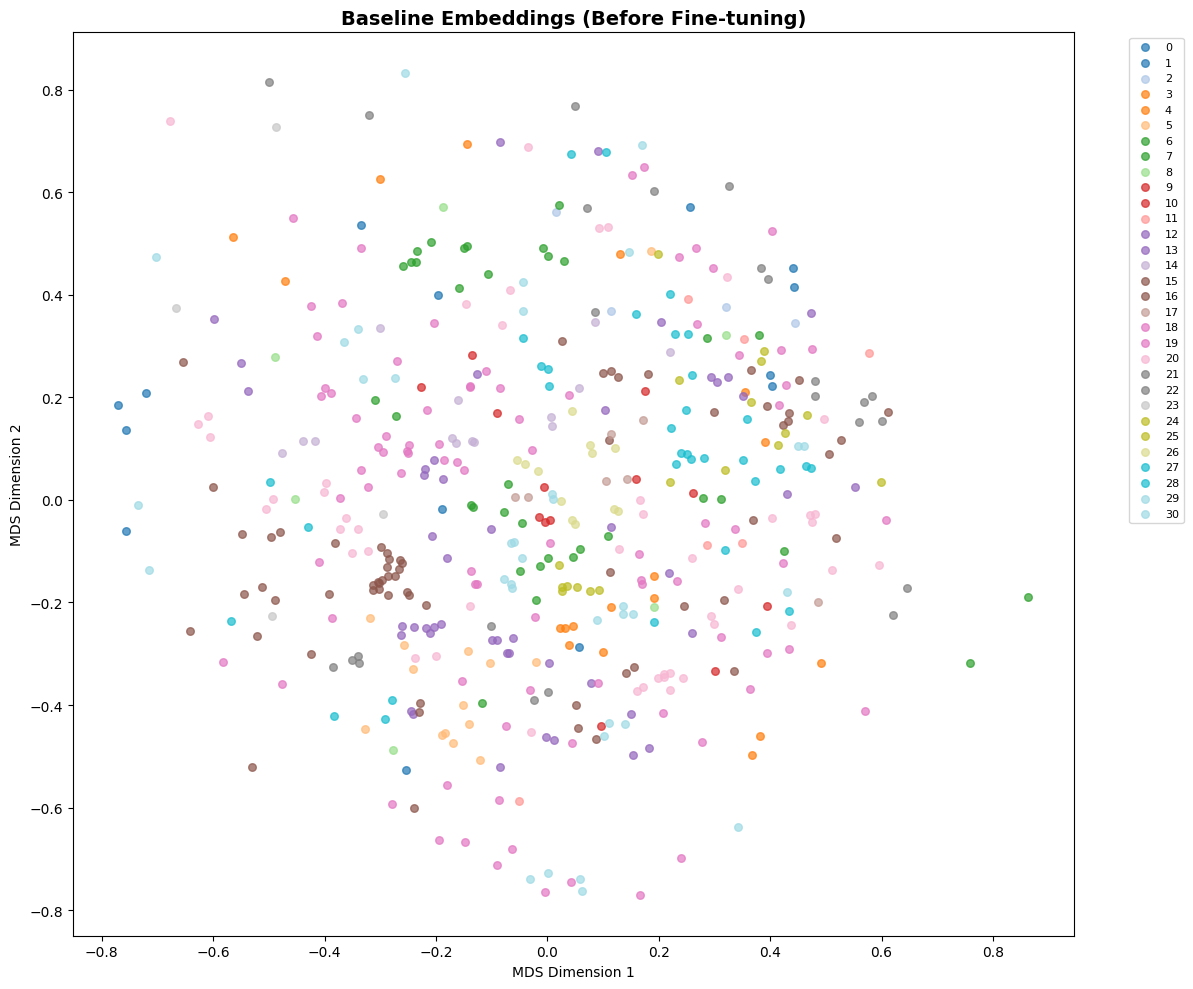

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
)
baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [ ]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

wandb.log({"num_projection_params": sum(p.numel() for p in model.parameters())})

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


During comparison, we initialize each experiment with the same model weights to ensure that differences in performance are not influenced by variations in initialization.


In [17]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

Initial model weights saved to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/model_initial_weights.pth


In [ ]:
table = [
    ["Loss Function", "Best val_mAP", "Best epoch", "Training time"]
]

## ArcFace Loss

ArcFace Loss adds an additive angular margin to the target class in the normalized embedding space. By enforcing a margin between classes on the hypersphere, it increases inter-class separation and reduces intra-class variation, leading to more discriminative embeddings.

It was used as the baseline loss function.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ArcFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["arcface_margin"],
    scale=config["arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"], 
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: ArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"ArcFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ArcFace margin: {config['arcface_margin']}")
print(f"  ArcFace scale: {config['arcface_scale']}")

Training components initialized:
  Loss: ArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
ArcFace Loss:
  Embedding dim: 256
  Num classes: 31
  ArcFace margin: 0.5
  ArcFace scale: 64.0


In [ ]:
# Training loop
set_seeds(config['seed'])
arcface_checkpoint_path = CHECKPOINT_PATH / "best_arcface_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="arcface",
    checkpoint_path=arcface_checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist(),
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_arcface": best_map,
    "best_epoch_arcface": best_epoch,
    "total_epochs_arcface": len(history['train_loss']),
    "training_time_arcface": training_time,
})

table.append([
    "ArcFaceLoss",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 12 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.2790
  Val Loss:   31.5381
  Val mAP:    0.3402 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 31.7777
  Val Loss:   26.9871
  Val mAP:    0.3541 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.3672
  Val Loss:   23.5419
  Val mAP:    0.3793 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 25.4624
  Val Loss:   20.7698
  Val mAP:    0.4086 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.5488
  Val Loss:   2.9672
  Val mAP:    0.8438 | LR: 6.25e-06
  No improvement. Patience: 6/10

Epoch 91/200


  Train Loss: 0.5556
  Val Loss:   2.9587
  Val mAP:    0.8438 | LR: 6.25e-06
  No improvement. Patience: 7/10

Epoch 92/200


  Train Loss: 0.5600
  Val Loss:   2.9609
  Val mAP:    0.8441 | LR: 3.13e-06
  No improvement. Patience: 8/10

Epoch 93/200


  Train Loss: 0.5450
  Val Loss:   2.9828
  Val mAP:    0.8430 | LR: 3.13e-06
  No improvement. Patience: 9/10

Epoch 94/200


  Train Loss: 0.5406
  Val Loss:   3.0180
  Val mAP:    0.8444 | LR: 3.13e-06
  No improvement. Patience: 10/10

Early stopping triggered after 94 epochs

Training complete!
Best epoch: 84, Val mAP: 0.8460


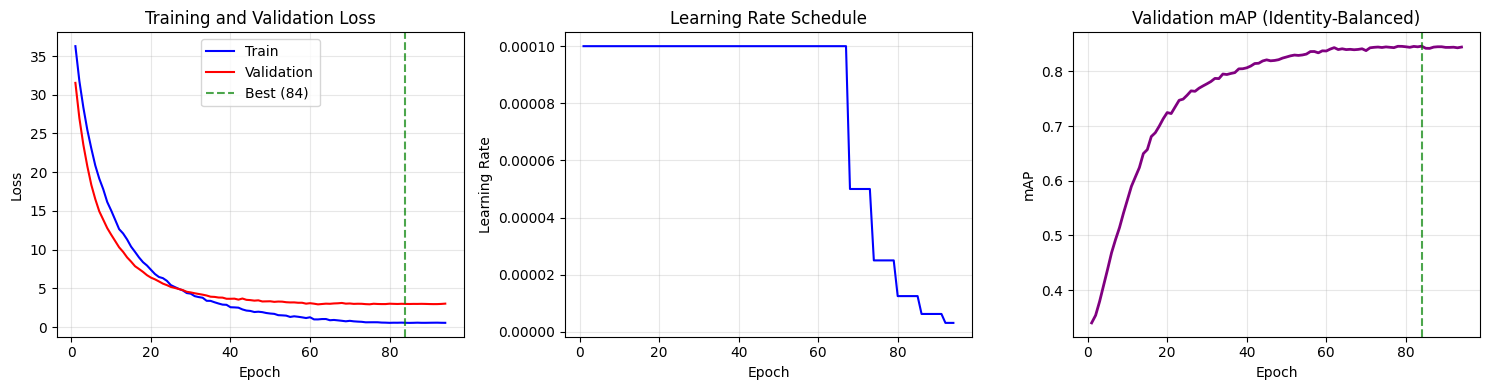

In [21]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_arcface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_arcface": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(arcface_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_arcface_model.pth
  Val Loss: 2.9815
  Val mAP: 0.8460


In [23]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


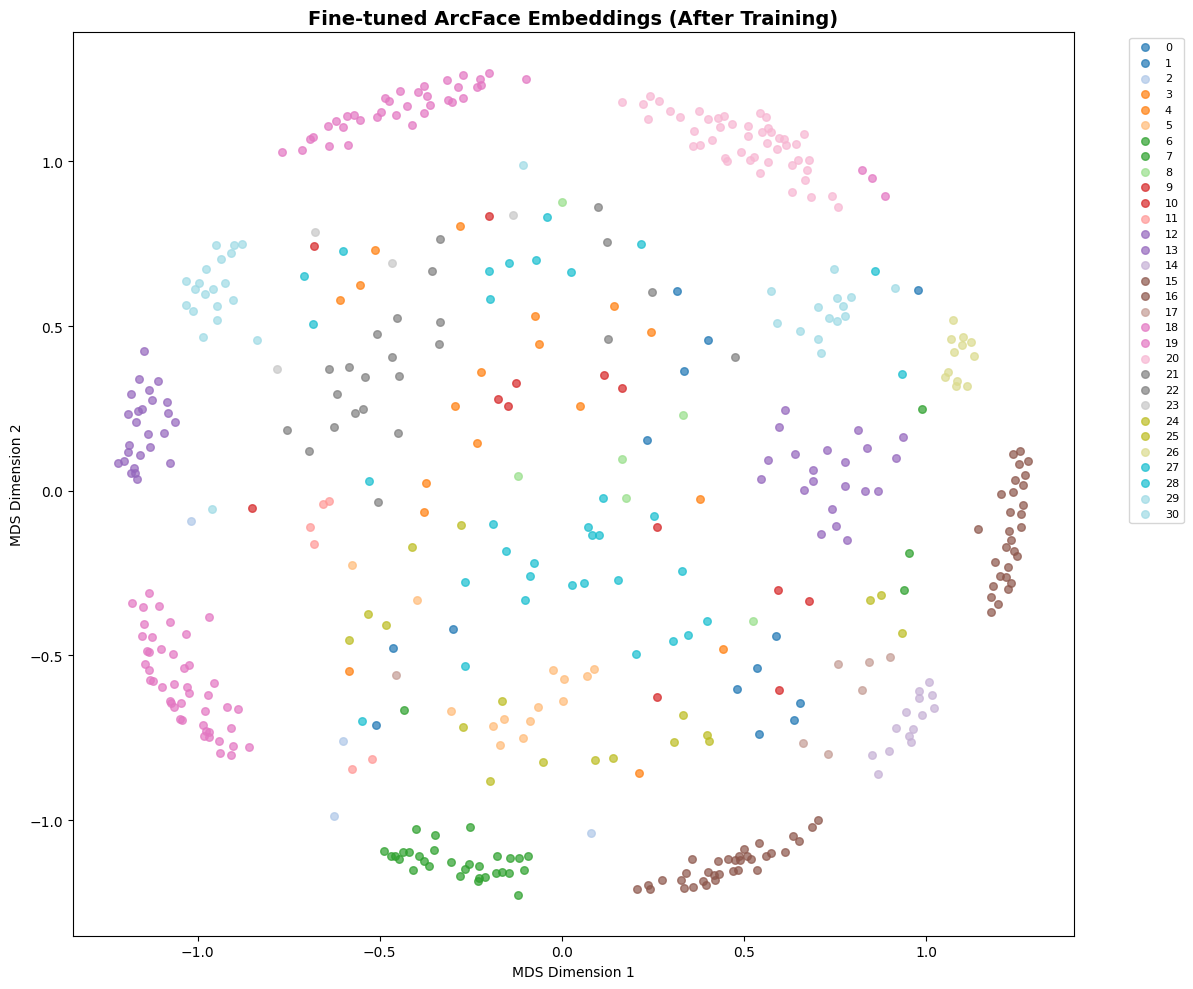

In [24]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "arcface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_arcface": wandb.Image(fig_finetuned)})

In [ ]:
random_idx = np.random.randint(0, len(val_labels))
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_arcface.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_arcface": wandb.Image(fig),
    "nearest_neighbors_stats_arcface": stats,
})


In [25]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## CosFace Loss

CosFace Loss introduces an additive cosine margin to the similarity score of the correct class. After normalization, the margin reduces the cosine similarity for the target class, forcing embeddings of the same class to cluster more tightly and improving class separability.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CosFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["cosface_margin"],
    scale=config["cosface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"], 
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: CosFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")


print(f"CosFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  CosFace margin: {config['cosface_margin']}")
print(f"  CosFace scale: {config['cosface_scale']}")

Training components initialized:
  Loss: CosFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
cosface_checkpoint_path = CHECKPOINT_PATH / "best_cosface_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="cosface",
    checkpoint_path=cosface_checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist(),
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_cosface": best_map,
    "best_epoch_cosface": best_epoch,
    "total_epochs_cosface": len(history['train_loss']),
    "training_time_cosface": training_time,
})

table.append([
    "CosFaceLoss",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 12 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.8367
  Val Loss:   32.3004
  Val mAP:    0.3314 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.1562
  Val Loss:   27.8833
  Val mAP:    0.3489 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 28.7501
  Val Loss:   24.2849
  Val mAP:    0.3702 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 25.9695
  Val Loss:   21.3807
  Val mAP:    0.3972 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1625
  Val Loss:   2.8434
  Val mAP:    0.8512 | LR: 1.25e-05
  No improvement. Patience: 6/10

Epoch 107/200


  Train Loss: 0.1810
  Val Loss:   2.8483
  Val mAP:    0.8492 | LR: 1.25e-05
  No improvement. Patience: 7/10

Epoch 108/200


  Train Loss: 0.2187
  Val Loss:   2.7869
  Val mAP:    0.8570 | LR: 6.25e-06
  No improvement. Patience: 8/10

Epoch 109/200


  Train Loss: 0.1960
  Val Loss:   2.8202
  Val mAP:    0.8553 | LR: 6.25e-06
  No improvement. Patience: 9/10

Epoch 110/200


  Train Loss: 0.2067
  Val Loss:   2.8297
  Val mAP:    0.8539 | LR: 6.25e-06
  No improvement. Patience: 10/10

Early stopping triggered after 110 epochs

Training complete!
Best epoch: 100, Val mAP: 0.8571


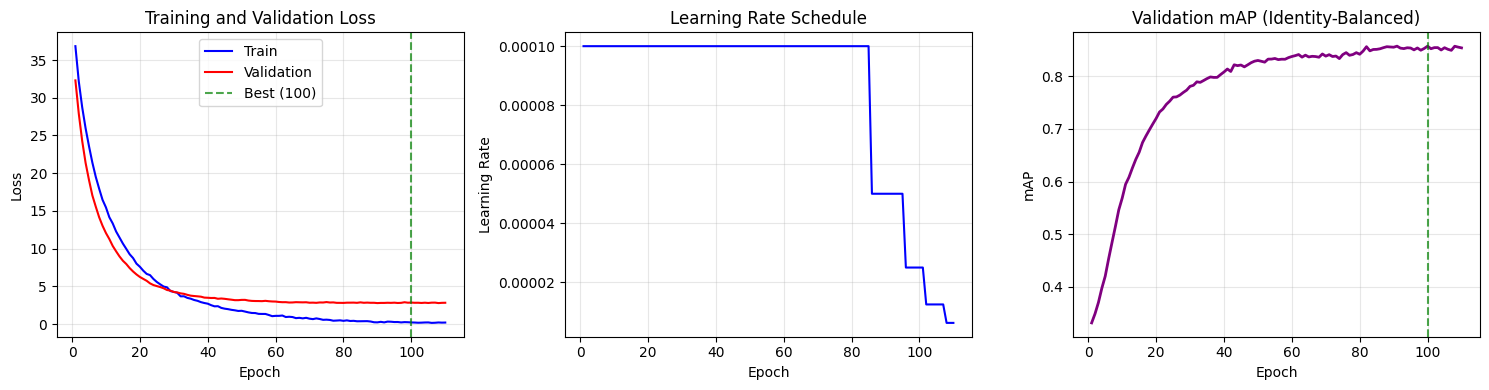

In [29]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_cosface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_cosface": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(cosface_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_cosface_model.pth
  Val Loss: 2.8541
  Val mAP: 0.8571


In [31]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


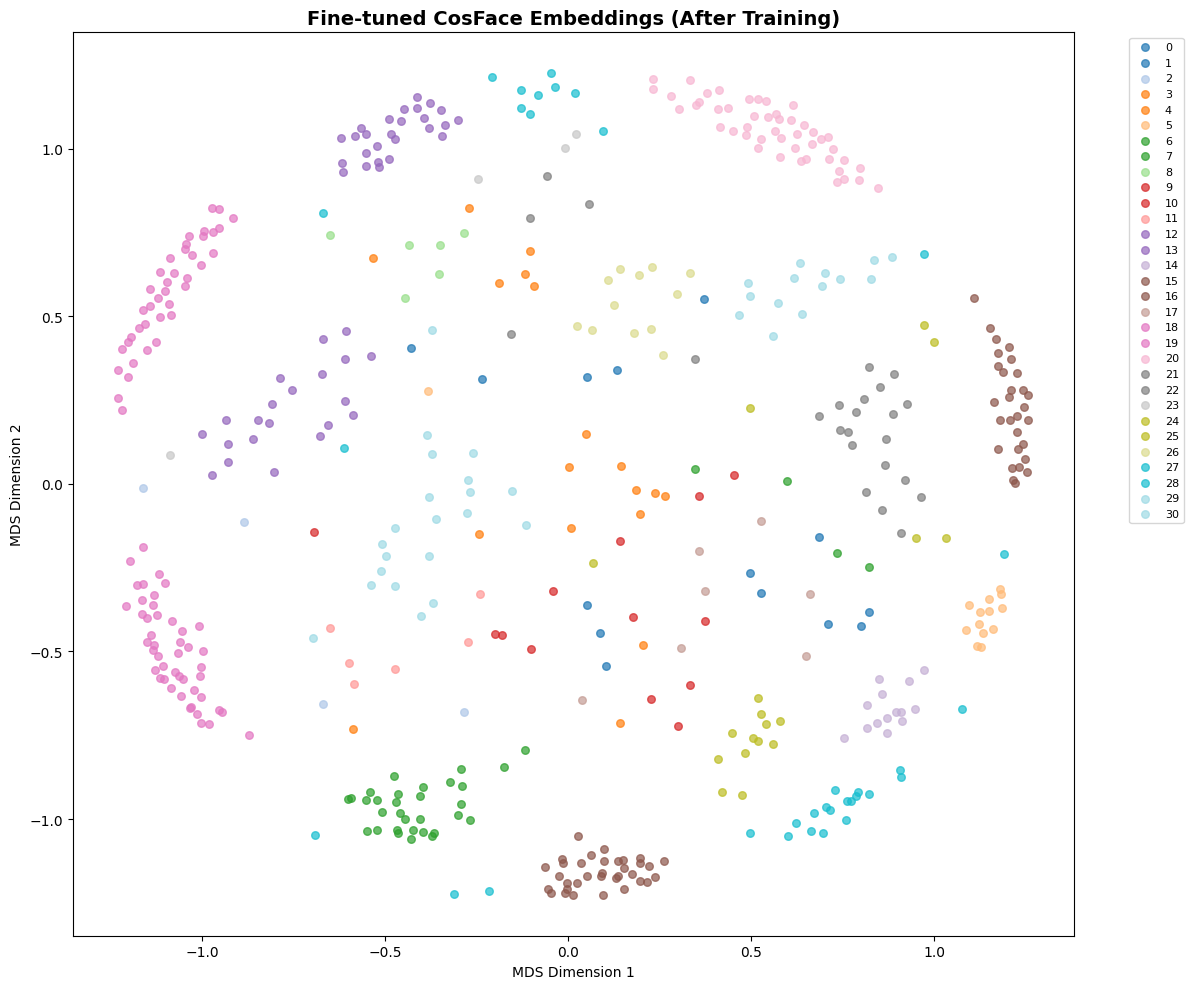

In [32]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned CosFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "cosface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_cosface": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_cosface.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_cosface": wandb.Image(fig),
    "nearest_neighbors_stats_cosface": stats,
})


In [33]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## SphereFace Loss

SphereFace Loss applies a multiplicative angular margin to the classification boundary. By increasing the angular distance required for correct classification, it encourages more discriminative feature embeddings on a hypersphere.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SphereFaceLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes,
    margin=config["sphereface_margin"],
    scale=config["sphereface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: SphereFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"SphereFace Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SphereFace margin: {config['sphereface_margin']}")
print(f"  SphereFace scale: {config['sphereface_scale']}")

Training components initialized:
  Loss: SphereFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
sphereface_checkpoint_path = CHECKPOINT_PATH / "best_sphereface_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="sphereface",
    checkpoint_path=sphereface_checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_sphereface": best_map,
    "best_epoch_sphereface": best_epoch,
    "total_epochs_sphereface": len(history['train_loss']),
    "training_time_sphereface": training_time
})

table.append([
    "SphereFaceLoss",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 12 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 197.9056
  Val Loss:   188.6453
  Val mAP:    0.3353 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 184.2917
  Val Loss:   167.4593
  Val mAP:    0.3603 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 169.7997
  Val Loss:   152.2172
  Val mAP:    0.3891 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 157.7178
  Val Loss:   141.4843
  Val mAP:    0.4202 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 18.9105
  Val Loss:   21.4279
  Val mAP:    0.8111 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 105/200


  Train Loss: 18.1913
  Val Loss:   21.4390
  Val mAP:    0.8132 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 106/200


  Train Loss: 17.4650
  Val Loss:   21.4729
  Val mAP:    0.8158 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 107/200


  Train Loss: 17.2767
  Val Loss:   21.0863
  Val mAP:    0.8178 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 108/200


  Train Loss: 16.7952
  Val Loss:   21.2697
  Val mAP:    0.8152 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 108 epochs

Training complete!
Best epoch: 98, Val mAP: 0.8205


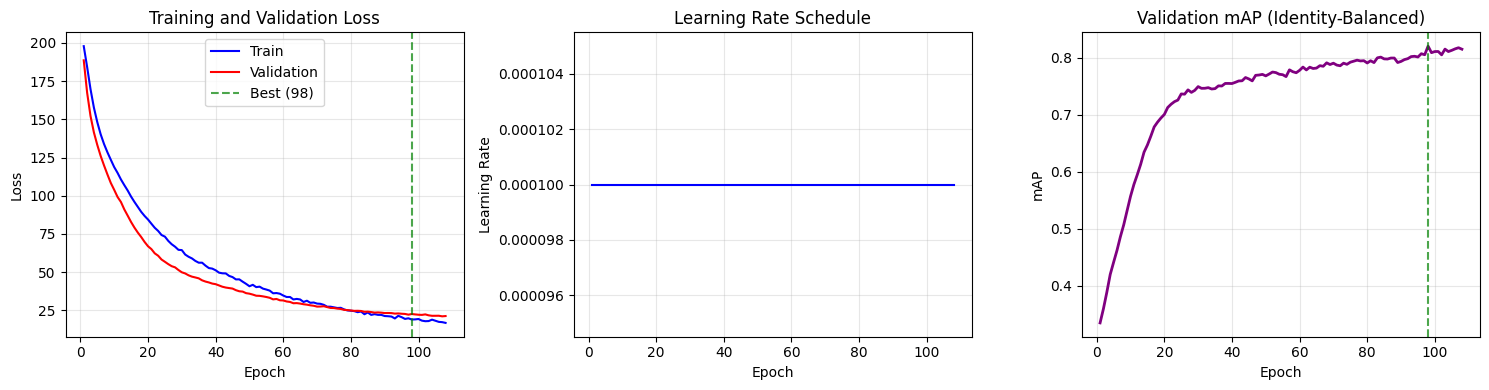

In [37]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sphereface.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sphereface": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(sphereface_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_sphereface_model.pth
  Val Loss: 22.5948
  Val mAP: 0.8205


In [39]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


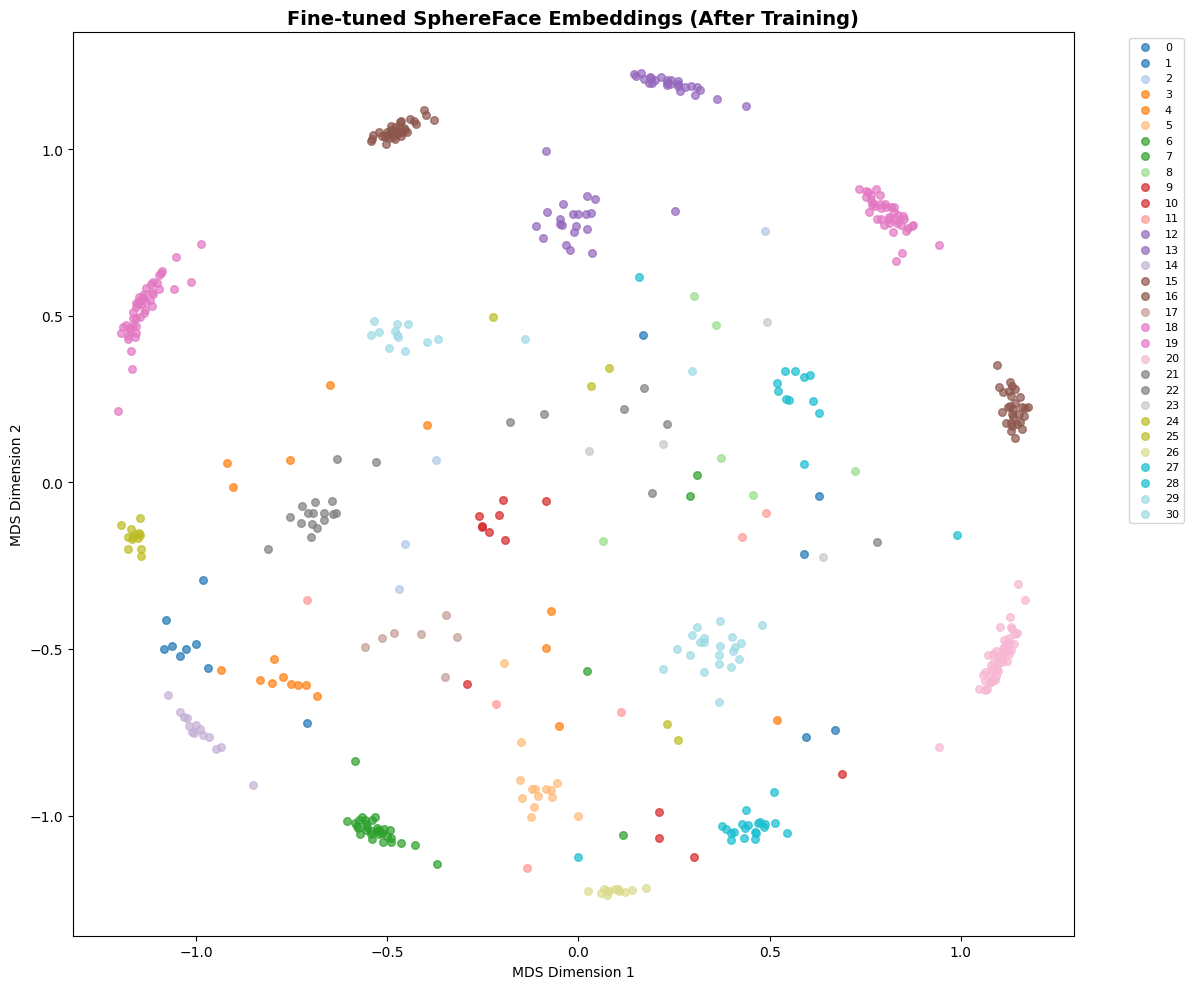

In [40]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SphereFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sphereface_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sphereface": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_sphereface.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_sphereface": wandb.Image(fig),
    "nearest_neighbors_stats_sphereface": stats,
})


In [41]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Proxy Anchor Loss

Proxy Anchor Loss uses learnable proxy vectors representing class centers instead of pairwise sample comparisons. Embeddings are pulled toward their corresponding proxy and pushed away from others, improving efficiency and stability in metric learning.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = ProxyAnchorLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    margin=config["proxyanchor_margin"], 
    alpha=config["proxyanchor_alpha"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"ProxyAnchor Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")

Training components initialized:
  Loss: ProxyAnchorLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
proxy_anchor_checkpoint_path = CHECKPOINT_PATH / "best_proxyanchor_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="proxyanchor",
    checkpoint_path=proxy_anchor_checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_proxyanchor": best_map,
    "best_epoch_proxyanchor": best_epoch,
    "total_epochs_proxyanchor": len(history['train_loss']),
    "training_time_proxyanchor": training_time
})

table.append([
    "ProxyAnchorLoss",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 12 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 9.8019
  Val Loss:   8.0361
  Val mAP:    0.3327 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 9.0058
  Val Loss:   7.6803
  Val mAP:    0.3367 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 8.6006
  Val Loss:   7.4652
  Val mAP:    0.3421 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 8.2784
  Val Loss:   7.2896
  Val mAP:    0.3444 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1726
  Val Loss:   0.6329
  Val mAP:    0.8779 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 142/200


  Train Loss: 0.1779
  Val Loss:   0.6315
  Val mAP:    0.8768 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 143/200


  Train Loss: 0.1716
  Val Loss:   0.6256
  Val mAP:    0.8776 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 144/200


  Train Loss: 0.1726
  Val Loss:   0.6349
  Val mAP:    0.8775 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 145/200


  Train Loss: 0.1668
  Val Loss:   0.6333
  Val mAP:    0.8806 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 145 epochs

Training complete!
Best epoch: 135, Val mAP: 0.8828


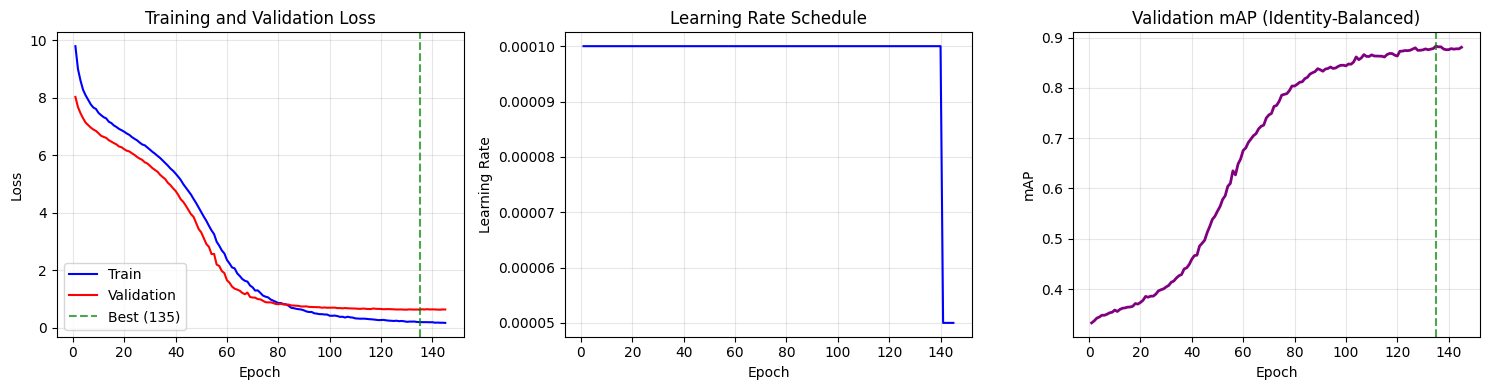

In [45]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_proxyanchor.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_proxyanchor": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(proxy_anchor_checkpoint_path, map_location=device, weights_only=False)   
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_proxyanchor_model.pth
  Val Loss: 0.6265
  Val mAP: 0.8828


In [47]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


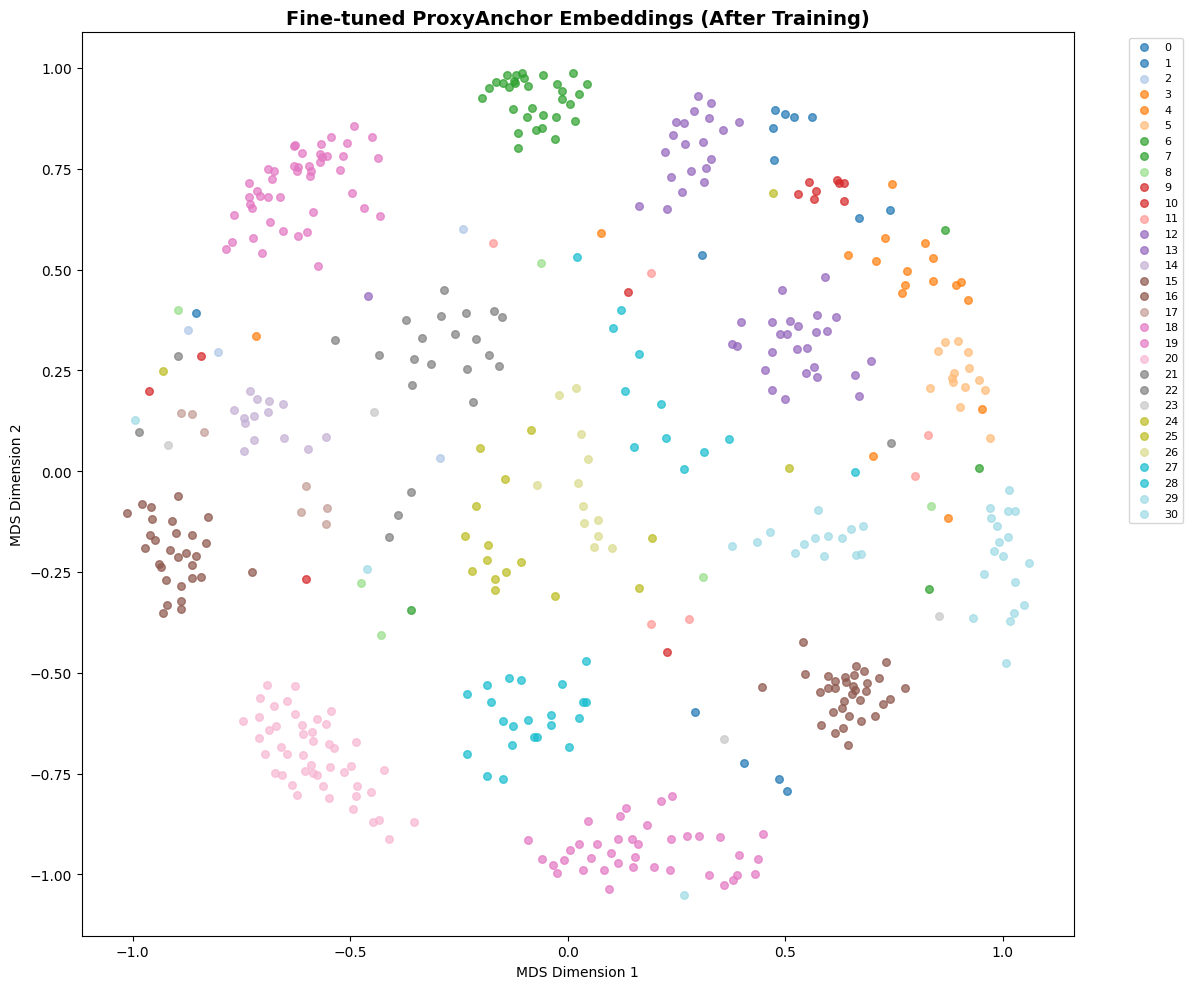

In [48]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned ProxyAnchor Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "proxyanchor_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_proxyanchor": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_proxyanchor.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_proxyanchor": wandb.Image(fig),
    "nearest_neighbors_stats_proxyanchor": stats,
})


In [49]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Sub-Center ArcFace Loss

Sub-Center ArcFace extends ArcFace by assigning multiple centers to each class. Each sample is matched with its nearest sub-center, allowing the model to capture intra-class variations and handle noisy samples more effectively.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = SubCenterArcFaceLoss(
    num_classes=num_classes, 
    embedding_dim=config["embedding_dim"], 
    k=config["subcenter_arcface_num_subcenters"],
    margin=config["subcenter_arcface_margin"],
    scale=config["subcenter_arcface_scale"]
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: SubCenterArcFaceLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"SubCenterArcFace Model:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  SubCenterArcFace k: {config['subcenter_arcface_num_subcenters']}")
print(f"  SubCenterArcFace margin: {config['subcenter_arcface_margin']}")
print(f"  SubCenterArcFace scale: {config['subcenter_arcface_scale']}")

Training components initialized:
  Loss: SubCenterArcFaceLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
subcenter_checkpoint_path = CHECKPOINT_PATH / "best_subcenterarcface_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="subcenterarcface",
    checkpoint_path=subcenter_checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_subcenterarcface": best_map,
    "best_epoch_subcenterarcface": best_epoch,
    "total_epochs_subcenterarcface": len(history['train_loss']),
    "training_time_subcenterarcface": training_time
})

table.append([
    "SubCenterArcFaceLoss",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 12 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 36.5795
  Val Loss:   33.0150
  Val mAP:    0.3330 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 32.7827
  Val Loss:   28.8029
  Val mAP:    0.3466 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 29.7451
  Val Loss:   25.3931
  Val mAP:    0.3646 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 26.9247
  Val Loss:   22.6997
  Val mAP:    0.3830 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.3849
  Val Loss:   2.9637
  Val mAP:    0.7085 | LR: 5.00e-05
  No improvement. Patience: 6/10

Epoch 93/200


  Train Loss: 0.3828
  Val Loss:   2.9881
  Val mAP:    0.7067 | LR: 5.00e-05
  No improvement. Patience: 7/10

Epoch 94/200


  Train Loss: 0.3873
  Val Loss:   2.9939
  Val mAP:    0.7067 | LR: 5.00e-05
  No improvement. Patience: 8/10

Epoch 95/200


  Train Loss: 0.3484
  Val Loss:   2.9914
  Val mAP:    0.7061 | LR: 5.00e-05
  No improvement. Patience: 9/10

Epoch 96/200


  Train Loss: 0.3621
  Val Loss:   2.9922
  Val mAP:    0.7057 | LR: 5.00e-05
  No improvement. Patience: 10/10

Early stopping triggered after 96 epochs

Training complete!
Best epoch: 86, Val mAP: 0.7090


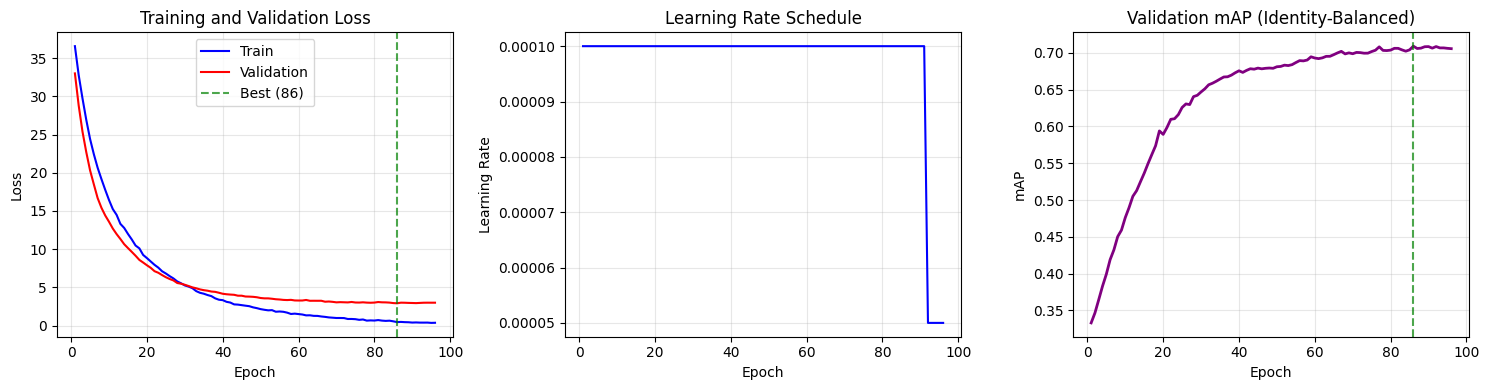

In [53]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_sub_center_arc_face.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_sub_center_arc_face": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(subcenter_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_subcenterarcface_model.pth
  Val Loss: 2.9139
  Val mAP: 0.7090


In [55]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


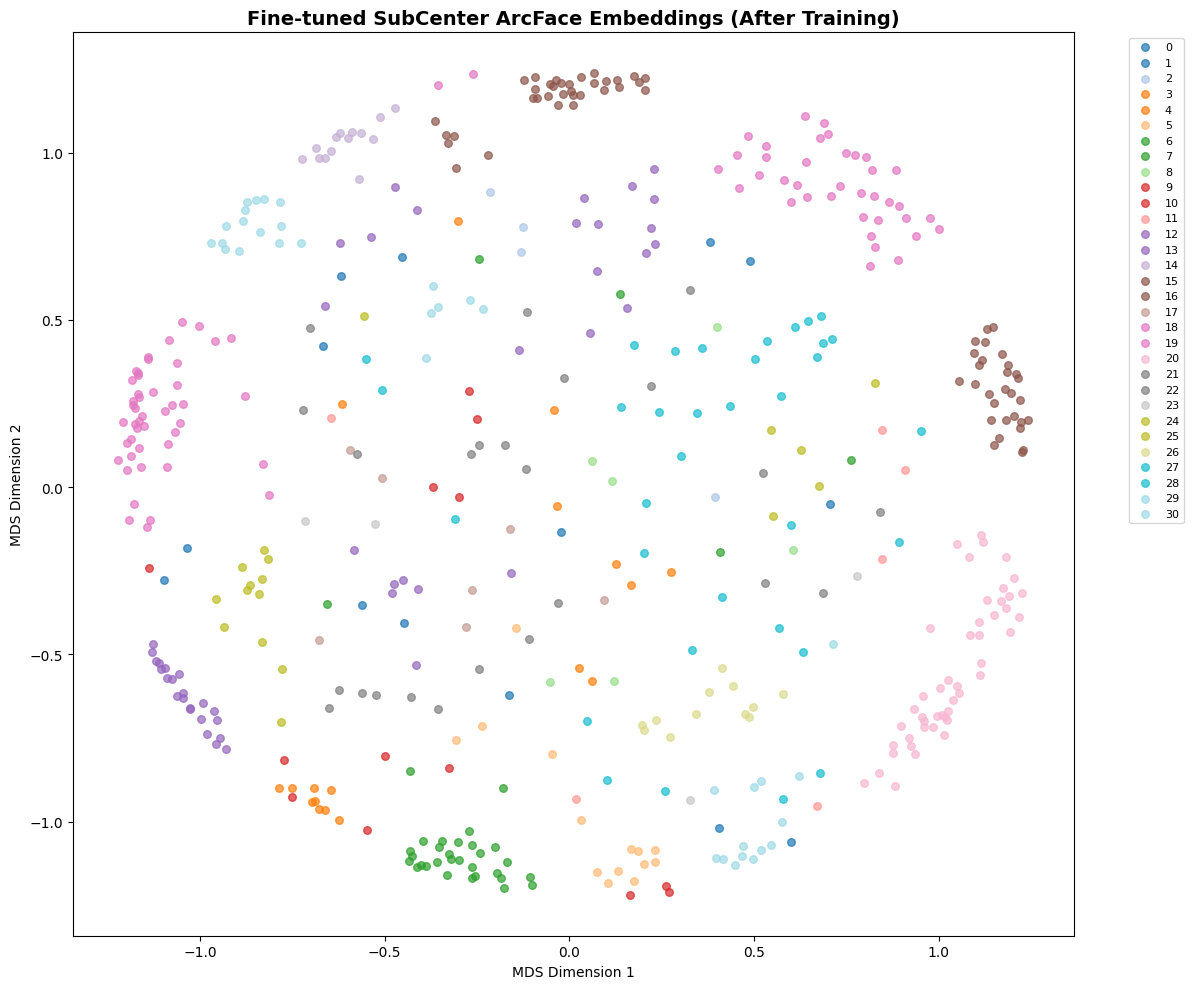

In [56]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned SubCenter ArcFace Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "sub_center_arc_face_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_sub_center_arc_face": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_sub_center_arc_face.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_sub_center_arc_face": wandb.Image(fig),
    "nearest_neighbors_stats_sub_center_arc_face": stats,
})


In [57]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Center Loss

Center Loss reduces intra-class variance by learning a center for each class and penalizing the distance between features and their corresponding center.

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = CenterLoss(
    embedding_dim=config["embedding_dim"],
    num_classes=num_classes
).to(device)

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patience=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: CenterLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")

print(f"Center Loss:")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")

Training components initialized:
  Loss: CenterLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
center_checkpoint_path = CHECKPOINT_PATH / "best_center_loss_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="center_loss",
    checkpoint_path=center_checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_center_loss": best_map,
    "best_epoch_center_loss": best_epoch,
    "total_epochs_center_loss": len(history['train_loss']),
    "training_time_center_loss": training_time
})

table.append([
    "Center Loss",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 12 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 479.7863
  Val Loss:   349.6567
  Val mAP:    0.3418 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 431.5557
  Val Loss:   320.7209
  Val mAP:    0.3651 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 393.8976
  Val Loss:   292.0561
  Val mAP:    0.3959 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 362.0927
  Val Loss:   274.9667
  Val mAP:    0.4224 | LR: 1.00e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 41.1801
  Val Loss:   36.1805
  Val mAP:    0.8138 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 97/200


  Train Loss: 40.9858
  Val Loss:   35.9102
  Val mAP:    0.8159 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 98/200


  Train Loss: 41.2199
  Val Loss:   35.5455
  Val mAP:    0.8203 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 99/200


  Train Loss: 41.2954
  Val Loss:   35.1208
  Val mAP:    0.8210 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 100/200


  Train Loss: 40.2487
  Val Loss:   35.1749
  Val mAP:    0.8211 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 100 epochs

Training complete!
Best epoch: 90, Val mAP: 0.8222


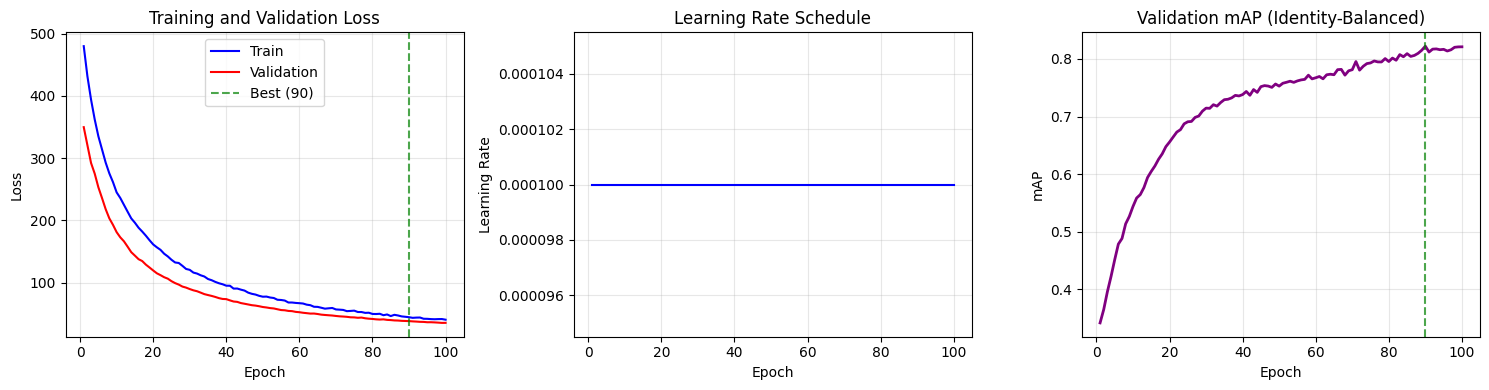

In [61]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_center_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_center_loss": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(center_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_center_loss_model.pth
  Val Loss: 37.9576
  Val mAP: 0.8222


In [63]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


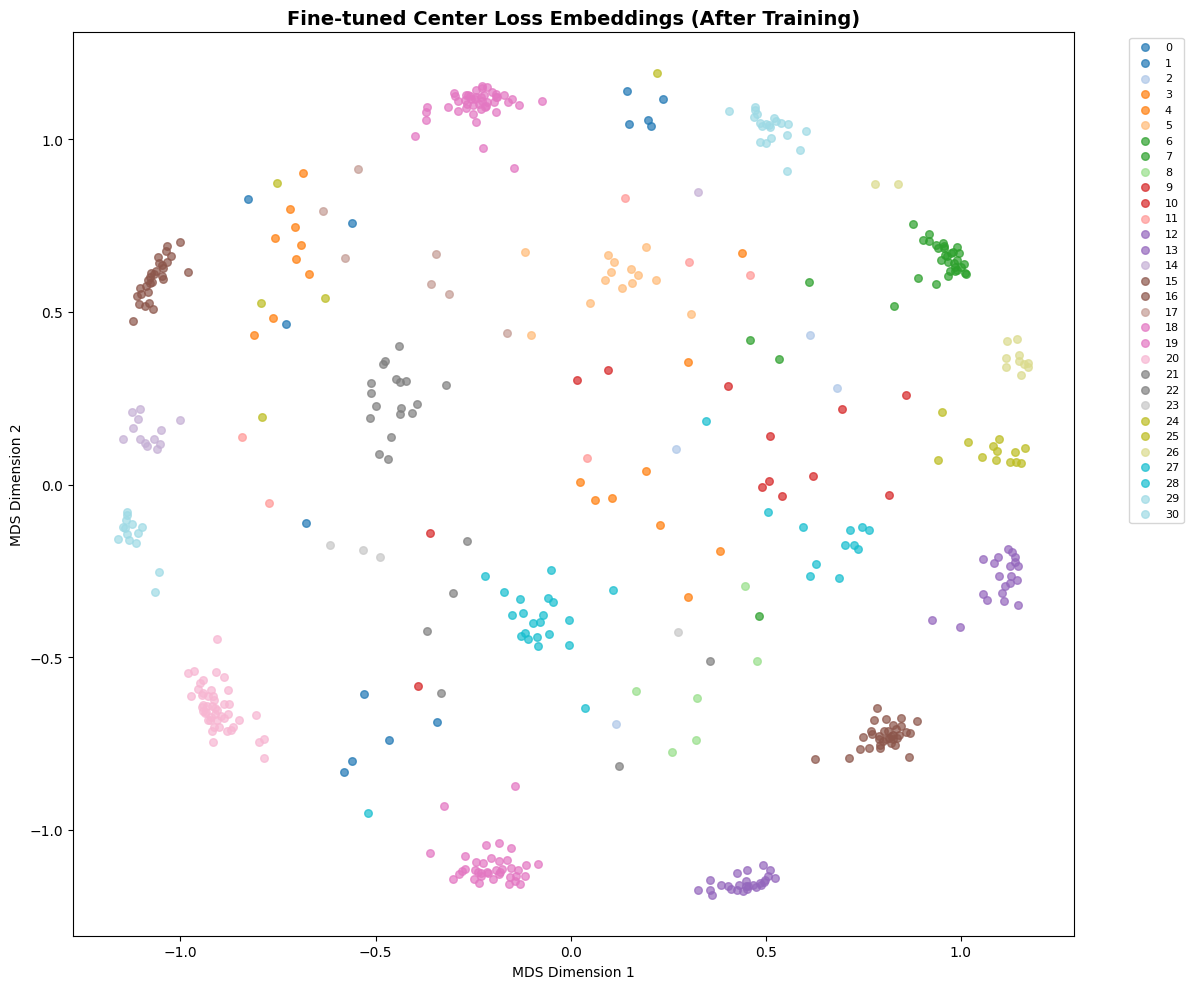

In [64]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Center Loss Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "center_loss_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_center_loss": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_center_loss.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_center_loss": wandb.Image(fig),
    "nearest_neighbors_stats_center_loss": stats,
})


In [65]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Batch-Hard Triplet Loss

Batch-Hard Triplet Loss selects the hardest positive and hardest negative samples within a mini-batch for each anchor. The loss encourages anchors to be closer to positives than negatives by a margin, focusing training on difficult examples

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path))

criterion = BatchHardTripletLoss(
    margin=config["batch_hard_triplet_margin"]
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=config["scheduler_factor"],
    patienc=e=config["scheduler_patience"],
)

print("Training components initialized:")
print(f"  Loss: BatchHardTripletLoss")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: ReduceLROnPlateau (factor={config['scheduler_factor']}, patience={config['scheduler_patience']})")


print(f"Batch Hard Triplet Loss:")
print(f"  Margin: {config['batch_hard_triplet_margin']}")

Training components initialized:
  Loss: BatchHardTripletLoss
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


In [ ]:
# Training loop
set_seeds(config['seed'])
batch_hard_checkpoint_path = CHECKPOINT_PATH / "best_batch_hard_triplet_model.pth"
start_time = time.time()
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="batch_hard_triplet",
    checkpoint_path=batch_hard_checkpoint_path,
    num_epochs=config['num_epochs'],
    patience=config['patience'],
    classes=label_encoder.classes_.tolist()
)
training_time = time.time() - start_time

wandb.log({
    "final_val_mAP_batch_hard_triplet": best_map,
    "best_epoch_batch_hard_triplet": best_epoch,
    "total_epochs_batch_hard_triplet": len(history['train_loss']),
    "training_time_batch_hard_triplet": training_time
})

table.append([
    "Batch Hard Triplet",
    best_map,
    best_epoch,
    training_time
])

All random seeds set to 12 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.3034
  Val Loss:   0.4142
  Val mAP:    0.3702 | LR: 1.00e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 0.2859
  Val Loss:   0.3837
  Val mAP:    0.3988 | LR: 1.00e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 0.2715
  Val Loss:   0.3667
  Val mAP:    0.4327 | LR: 1.00e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 0.0104
  Val Loss:   0.0655
  Val mAP:    0.7750 | LR: 1.00e-04
  No improvement. Patience: 6/10

Epoch 110/200


  Train Loss: 0.0089
  Val Loss:   0.0661
  Val mAP:    0.7708 | LR: 1.00e-04
  No improvement. Patience: 7/10

Epoch 111/200


  Train Loss: 0.0122
  Val Loss:   0.0659
  Val mAP:    0.7705 | LR: 1.00e-04
  No improvement. Patience: 8/10

Epoch 112/200


  Train Loss: 0.0128
  Val Loss:   0.0639
  Val mAP:    0.7736 | LR: 1.00e-04
  No improvement. Patience: 9/10

Epoch 113/200


  Train Loss: 0.0093
  Val Loss:   0.0640
  Val mAP:    0.7727 | LR: 1.00e-04
  No improvement. Patience: 10/10

Early stopping triggered after 113 epochs

Training complete!
Best epoch: 103, Val mAP: 0.7790


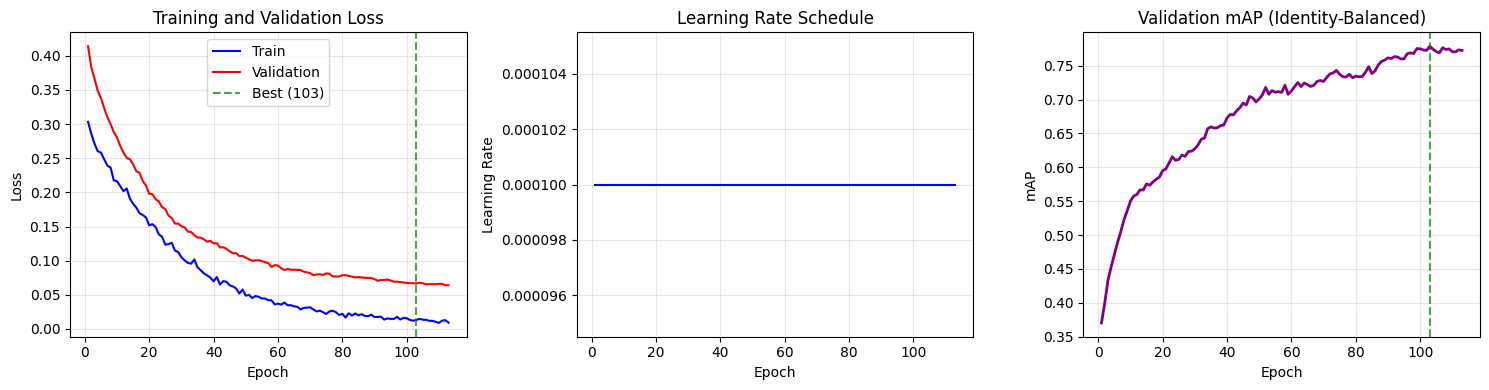

In [69]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_batch_hard_triplet.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_batch_hard_triplet": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(batch_hard_checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {best_epoch}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/checkpoints/loss/best_batch_hard_triplet_model.pth
  Val Loss: 0.0665
  Val mAP: 0.7790


In [71]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


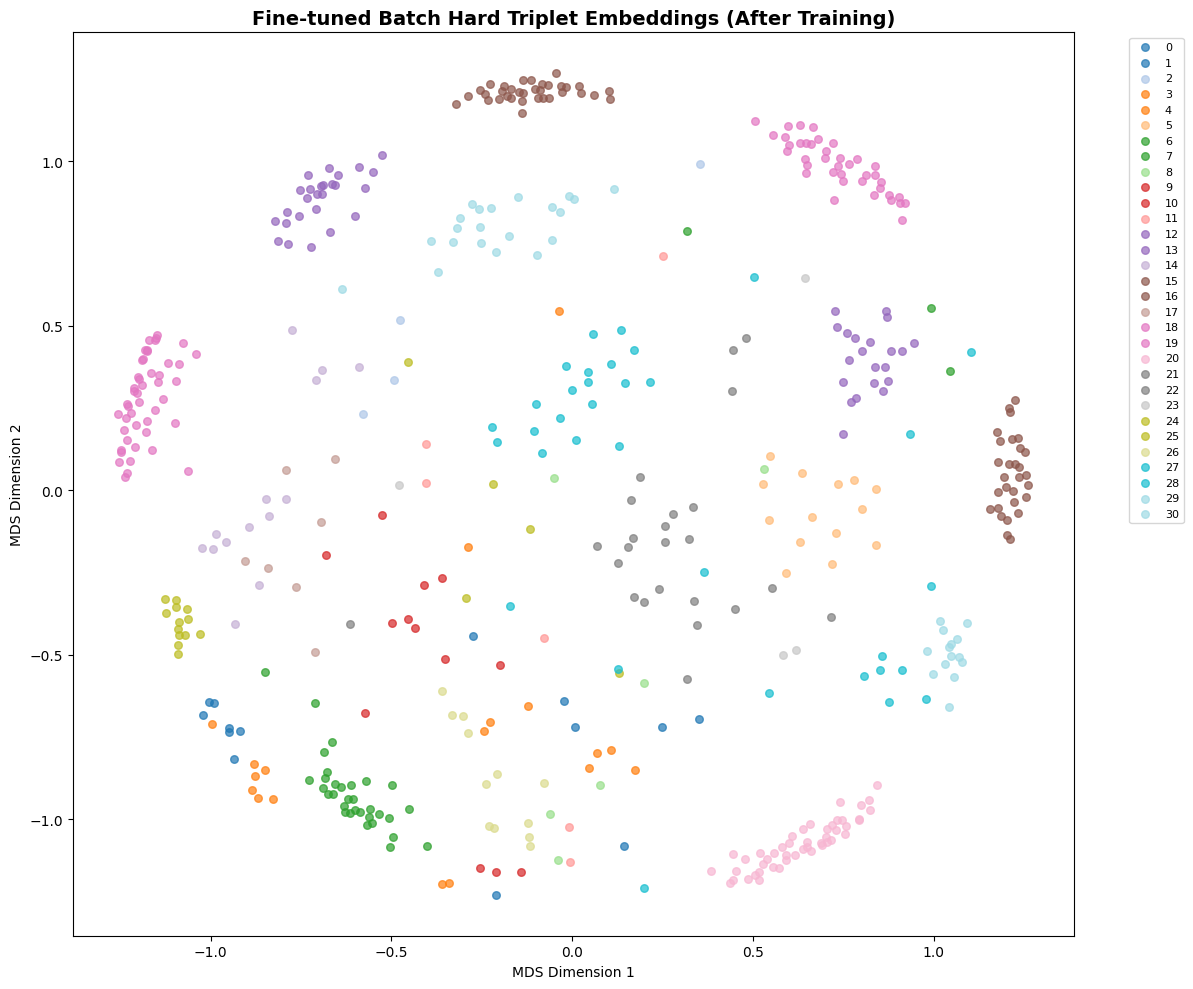

In [72]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Batch Hard Triplet Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "batch_hard_triplet_embeddings_mds_finetuned.png")
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds_batch_hard_triplet": wandb.Image(fig_finetuned)})

In [ ]:
fig, stats = visualize_nearest_neighbors(
    query_idx=random_idx,
    original_embeddings=baseline_embeddings[~train_mask],
    finetuned_embeddings=finetuned_embeddings[~train_mask],
    image_paths=image_paths[~train_mask],
    labels=val_labels,
)

fig.savefig(OUTPUT_PATH / "nearest_neighbors_batch_hard_triplet.png", dpi=150, bbox_inches='tight')
fig.show()


wandb.log({
    "nearest_neighbors_batch_hard_triplet": wandb.Image(fig),
    "nearest_neighbors_stats_batch_hard_triplet": stats,
})


In [73]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [74]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+-----------------+-----------+------------+--------------+---------------+--------------------+---------------+----------------------+
| Loss Function   |   ArcFace |    CosFace |   SphereFace |   ProxyAnchor |   SubCenterArcFace |   Center Loss |   Batch Hard Triplet |
+=================+===========+============+==============+===============+====================+===============+======================+
| Best val_mAP    |  0.846008 |   0.857099 |     0.820517 |      0.882779 |           0.709046 |      0.822209 |             0.778971 |
+-----------------+-----------+------------+--------------+---------------+--------------------+---------------+----------------------+
| Best epoch      | 84        | 100        |    98        |    135        |          86        |     90        |           103        |
+-----------------+-----------+------------+--------------+---------------+--------------------+---------------+----------------------+


In [ ]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

Result with random seed 42:

| Rank | Loss Function        | Best val_mAP | Best Epoch |
|-----:|----------------------|-------------:|-----------:|
| 1    | SphereFace           | **0.852**    | 167        |
| 2    | Center Loss          | 0.833        | 150        |
| 3    | ProxyAnchor          | 0.826        | 124        |
| 4    | ArcFace              | 0.810        | 90         |
| 5    | CosFace              | 0.805        | 72         |
| 6    | Batch Hard Triplet   | 0.761        | 128        |
| 7    | SubCenterArcFace     | 0.722        | 89         |

Result with random seed 66:
| Rank | Loss Function        | Best val_mAP | Best Epoch |
|-----:|----------------------|-------------:|-----------:|
| 1    | SphereFace           | **0.860**    | 164        |
| 2    | Center Loss          | 0.859        | 150        |
| 3    | ProxyAnchor          | 0.857        | 117        |
| 4    | CosFace              | 0.816        | 76         |
| 5    | ArcFace              | 0.809        | 64         |
| 6    | Batch Hard Triplet   | 0.739        | 125        |
| 7    | SubCenterArcFace     | 0.686        | 109        |

Result with random seed 102:
| Rank | Loss Function        | Best val_mAP | Best Epoch |
|-----:|----------------------|-------------:|-----------:|
| 1    | ProxyAnchor          | **0.839**    | 142        |
| 2    | SphereFace           | 0.815        | 108        |
| 3    | CosFace              | 0.796        | 67         |
| 4    | ArcFace              | 0.793        | 90         |
| 5    | Center Loss          | 0.786        | 92         |
| 6    | Batch Hard Triplet   | 0.761        | 68         |
| 7    | SubCenterArcFace     | 0.732        | 130        |

Result with random seed 305:
| Rank | Loss Function        | Best val_mAP | Best Epoch |
|-----:|----------------------|-------------:|-----------:|
| 1    | ProxyAnchor          | **0.826**    | 134        |
| 2    | Center Loss          | 0.825        | 133        |
| 3    | ArcFace              | 0.814        | 60         |
| 4    | CosFace              | 0.809        | 78         |
| 5    | SphereFace           | 0.800        | 109        |
| 6    | Batch Hard Triplet   | 0.757        | 140        |
| 7    | SubCenterArcFace     | 0.725        | 110        |

Result with random seed 12:
| Rank | Loss Function        | Best val_mAP | Best Epoch |
|-----:|----------------------|-------------:|-----------:|
| 1    | ProxyAnchor          | **0.883**    | 135        |
| 2    | CosFace              | 0.857        | 100        |
| 3    | ArcFace              | 0.846        | 84         |
| 4    | Center Loss          | 0.822        | 90         |
| 5    | SphereFace           | 0.821        | 98         |
| 6    | Batch Hard Triplet   | 0.779        | 103        |
| 7    | SubCenterArcFace     | 0.709        | 86         |

| Rank | Loss Function      | Seed 42 | Seed 66 | Seed 102 | Seed 305 | Seed 12 | **Mean mAP** | **Std** |
| ---: | ------------------ | ------: | ------: | -------: | -------: | ------: | -----------: | ------: |
|    1 | **ProxyAnchor**    |   0.826 |   0.857 |    0.839 |    0.826 |   0.883 |    **0.846** |   0.023 |
|    2 | **SphereFace**     |   0.852 |   0.860 |    0.815 |    0.800 |   0.821 |    **0.830** |   0.025 |
|    3 | **Center Loss**    |   0.833 |   0.859 |    0.786 |    0.825 |   0.822 |    **0.825** |   0.024 |
|    4 | **CosFace**        |   0.805 |   0.816 |    0.796 |    0.809 |   0.857 |    **0.817** |   0.022 |
|    5 | **ArcFace**        |   0.810 |   0.809 |    0.793 |    0.814 |   0.846 |    **0.814** |   0.017 |
|    6 | Batch Hard Triplet |   0.761 |   0.739 |    0.761 |    0.757 |   0.779 |    **0.759** |   0.013 |
|    7 | SubCenterArcFace   |   0.722 |   0.686 |    0.732 |    0.725 |   0.709 |    **0.715** |   0.017 |

Short interpretation

Across five random seeds, ProxyAnchor achieves the highest average validation mAP (0.846) and consistently ranks within the top three runs. Although SphereFace obtains the best result in some individual seeds, its mean performance is slightly lower and shows similar variance. Center Loss follows closely behind.

Angular margin losses (ArcFace and CosFace) show relatively stable results but slightly lower mean performance. Batch Hard Triplet and SubCenterArcFace consistently perform worse across all runs.

Overall, ProxyAnchor provides the best trade-off between performance and robustness across random seeds, making it the most reliable loss function in this comparison.

**Training Stability Note**

## Submission

In [ ]:
submission_model = "proxyanchor"

submission_dict = {
    "arcface": arcface_checkpoint_path,
    "cosface": cosface_checkpoint_path,
    "sphereface": sphereface_checkpoint_path,
    "proxyanchor": proxy_anchor_checkpoint_path,
    "subcenter": subcenter_checkpoint_path,
    "center": center_checkpoint_path,
    "batchhard": batch_hard_checkpoint_path
}

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

checkpoint_path = submission_dict[submission_model]

wandb.log({"submission_type": submission_model})

In [ ]:
# Create model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=model,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [01:00<00:00,  5.00s/it]

Test embeddings shape: (371, 768)


In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 29986.19it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9962
  Mean: 0.0686
  Std: 0.1402


In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.480112
1       1    0.154116
2       2    0.209182
3       3    0.201412
4       4    0.156037
5       5    0.029254
6       6    0.000000
7       7    0.078033
8       8    0.263681
9       9    0.076456



Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [ ]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/backbone/submission.csv
File size: 1802.3 KB


## Artifacts

In [ ]:
# Save model as W&B artifact
for key in submission_dict:
    checkpoint_path = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"arcface-model-{key}",
        type="model",
        description="ArcFace fine-tuned MegaDescriptor model for jaguar re-identification with loss: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [ ]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} loss"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [ ]:
wandb.finish()

best_epoch_baseline,▁
best_epoch_bg_image,▁
best_epoch_blur_bg,▁
best_epoch_const_bg,▁
best_epoch_extend_fg,▁
best_epoch_noise_bg,▁
best_epoch_sample_fg,▁
epoch,▃▄▅▅▇▁▂▂▄▄▅▆▇▇█▂▂▃▃▄▅▅▇█▁▂▃▃▇▇▁▃▆▇▁▆▇▄▄▆
final_val_mAP_baseline,▁
final_val_mAP_bg_image,▁
+21,...


Public submission score for seed 12 and blur version: 